# Project 002: The Classification Engine
## Notebook 2: Silicon Timing Test Pass/Fail Prediction

**The AI Engineering Lab** | Post 2 of the Progressive AIML Series

---

### Problem Statement

In post-silicon validation, every chip must pass a battery of timing tests at multiple voltage and temperature corners. Physical testing at all corners is expensive and time-consuming. The goal is to predict whether a chip will **pass** (1) or **fail** (0) a critical timing test based on measurable electrical characteristics, enabling engineers to prioritize which corners to test physically and which can be predicted with high confidence.

### What This Notebook Covers

1. Domain-specific EDA: understanding voltage/temperature/process corner interactions
2. Encoding process corners (slow/typical/fast) as ordinal features
3. Logistic Regression with L1/L2 regularization and cross-validation
4. Handling class imbalance in a production silicon context
5. Decision boundary visualization in voltage-temperature space
6. Cost-sensitive threshold tuning: the cost of missing a failing chip
7. Multi-class extension: predicting pass/marginal/fail (3-class)
8. Probability calibration and reliability diagrams

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
COLORS = {'pass': '#4CAF50', 'fail': '#F44336', 'primary': '#2196F3', 'secondary': '#FF9800'}
print('Libraries loaded.')

Libraries loaded.


## 1. Load and Explore the Silicon Dataset

The silicon timing dataset captures the key electrical parameters that determine whether a chip meets its timing closure requirements. VDD (supply voltage) and junction temperature are the primary drivers — higher voltage increases drive strength and Fmax, while higher temperature slows transistors. Process corner encodes the manufacturing variation: fast corners have shorter transistors (higher speed), slow corners have longer transistors (lower speed, more margin).

In [2]:
df = pd.read_csv('../data/silicon_timing_test_data.csv')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())

# Process corner mapping
corner_map = {0: 'Slow', 1: 'Typical', 2: 'Fast'}
df['corner_label'] = df['process_corner'].map(corner_map)

vc = df['timing_pass'].value_counts()
print(f'\nClass Distribution:')
print(f'  PASS (1): {vc[1]} ({vc[1]/len(df)*100:.1f}%)')
print(f'  FAIL (0): {vc[0]} ({vc[0]/len(df)*100:.1f}%)')

Shape: (3000, 8)

First 5 rows:


,vdd_core,junction_temp,process_corner,leakage_current,ring_osc_freq,ir_drop_mv,metal_resistance,timing_pass
0,0.955,39.0,1,76.06,1069.8,42.50,1.484,0
1,0.736,27.3,1,33.25,1053.4,33.17,2.303,1
2,0.727,68.6,0,77.67,1284.5,19.72,3.012,1
3,1.022,56.4,1,6.73,1231.8,59.00,3.350,1
4,0.931,25.2,0,22.34,1048.9,37.97,1.862,1



Class Distribution:
  PASS (1): 2143 (71.4%)
  FAIL (0): 857 (28.6%)


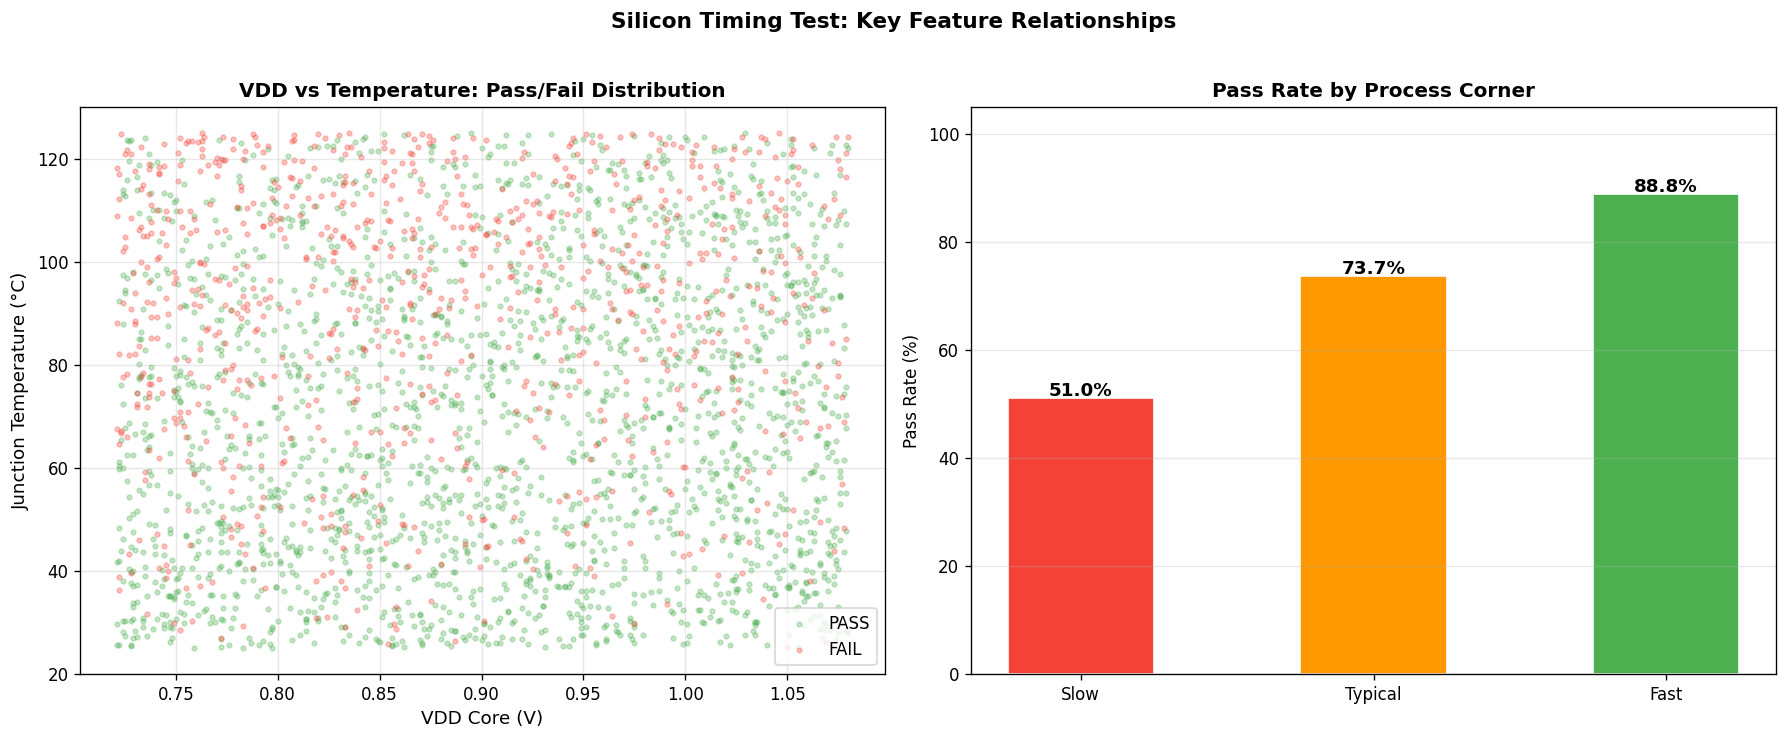

In [3]:
# VDD vs Temperature scatter colored by pass/fail
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for label, color, name in [(1, COLORS['pass'], 'PASS'), (0, COLORS['fail'], 'FAIL')]:
    mask = df['timing_pass'] == label
    axes[0].scatter(df[mask]['vdd_core'], df[mask]['junction_temp'],
                   alpha=0.3, s=8, color=color, label=name)
axes[0].set_xlabel('VDD Core (V)', fontsize=11)
axes[0].set_ylabel('Junction Temperature (°C)', fontsize=11)
axes[0].set_title('VDD vs Temperature: Pass/Fail Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Pass rate by process corner
corner_pass = df.groupby('corner_label')['timing_pass'].mean() * 100
corner_pass = corner_pass.reindex(['Slow', 'Typical', 'Fast'])
bars = axes[1].bar(corner_pass.index, corner_pass.values,
                   color=[COLORS['fail'], COLORS['secondary'], COLORS['pass']], edgecolor='white', width=0.5)
for bar, val in zip(bars, corner_pass.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Pass Rate by Process Corner', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Pass Rate (%)')
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Silicon Timing Test: Key Feature Relationships', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Preprocessing and Model Training

The process corner feature is ordinal (Slow < Typical < Fast) but we keep it as a numeric 0/1/2 since logistic regression can use the ordinal relationship. We apply StandardScaler to all features and use SMOTE to handle the class imbalance.

In [4]:
FEATURES = ['vdd_core', 'junction_temp', 'process_corner',
            'leakage_current', 'ring_osc_freq', 'ir_drop_mv', 'metal_resistance']
TARGET = 'timing_pass'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_s, y_train)

print(f'Train: {X_train_s.shape[0]} samples | After SMOTE: {X_train_sm.shape[0]} samples')
print(f'Test:  {X_test_s.shape[0]} samples')

Train: 2400 samples | After SMOTE: 3428 samples
Test:  600 samples


In [5]:
# Train multiple models
models = {
    'Baseline L2': LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    'L2 + Balanced': LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42),
    'L1 + SMOTE': LogisticRegression(C=0.5, penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    'L2 + SMOTE + CV': LogisticRegressionCV(Cs=20, cv=5, penalty='l2', scoring='f1', solver='lbfgs', max_iter=1000, random_state=42),
}

trained = {}
for name, model in models.items():
    if 'SMOTE' in name:
        model.fit(X_train_sm, y_train_sm)
    else:
        model.fit(X_train_s, y_train)
    trained[name] = model

# Evaluation
rows = []
for name, model in trained.items():
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy': f'{accuracy_score(y_test, y_pred):.4f}',
        'Precision': f'{precision_score(y_test, y_pred):.4f}',
        'Recall': f'{recall_score(y_test, y_pred):.4f}',
        'F1': f'{f1_score(y_test, y_pred):.4f}',
        'AUC-ROC': f'{roc_auc_score(y_test, y_prob):.4f}',
        'MCC': f'{matthews_corrcoef(y_test, y_pred):.4f}',
    })

display(pd.DataFrame(rows))

,Model,Accuracy,Precision,Recall,F1,AUC-ROC,MCC
0,Baseline L2,0.8017,0.8312,0.9068,0.8673,0.8507,0.4847
1,L2 + Balanced,0.7667,0.8895,0.7692,0.8250,0.8508,0.4920
2,L1 + SMOTE,0.7733,0.8886,0.7809,0.8313,0.8513,0.5000
3,L2 + SMOTE + CV,0.7750,0.8889,0.7832,0.8327,0.8513,0.5027


## 3. Decision Boundary Visualization in VDD-Temperature Space

We visualize the learned decision boundary in the two most important feature dimensions: VDD and junction temperature. The boundary shows the line at which the model transitions from predicting PASS to FAIL. The probability contours show how confident the model is at each point in the feature space.

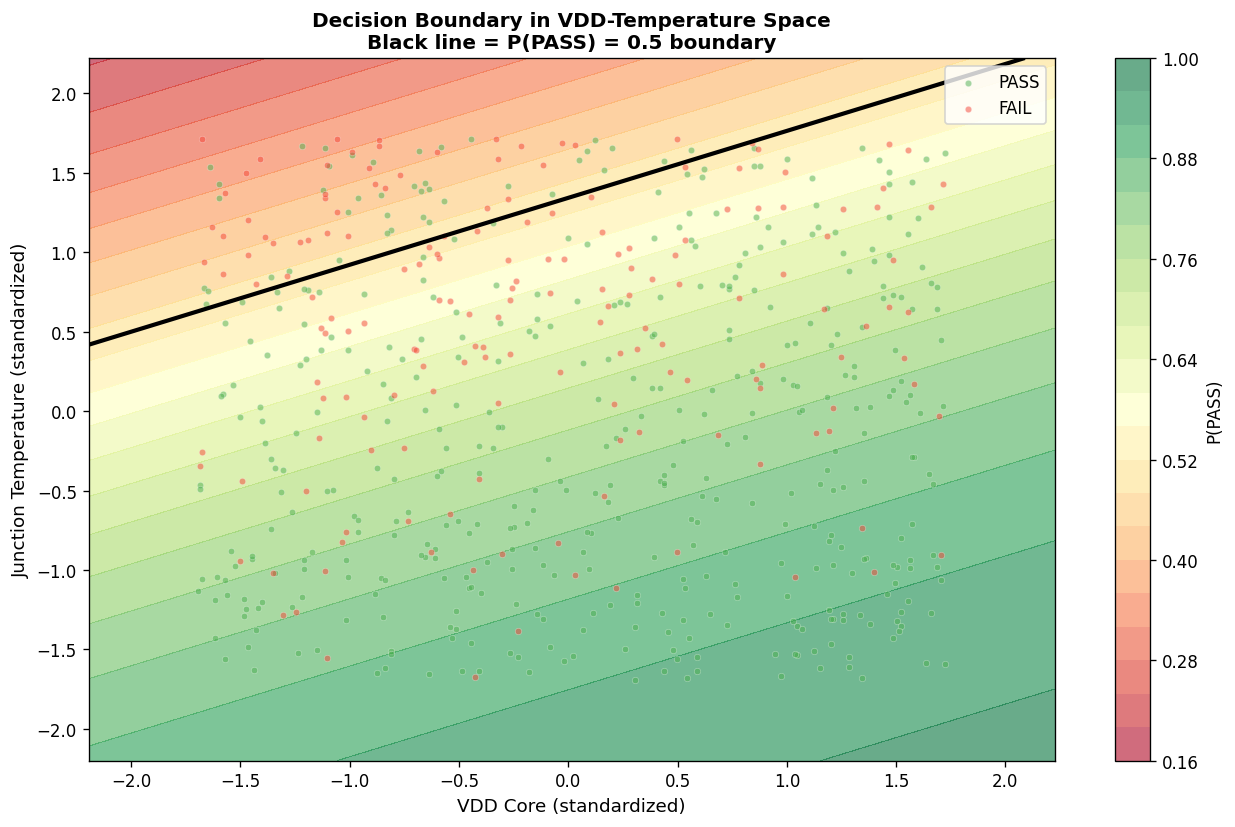

In [6]:
best_model = trained['L2 + SMOTE + CV']

# Use only VDD and Temp for 2D visualization (indices 0 and 1)
# Create a 2D model for visualization
X_2d = X_train_s[:, [0, 1]]  # VDD and Temp
lr_2d = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_2d.fit(X_2d, y_train)

# Create mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = lr_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(11, 7))
contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=0.6)
plt.colorbar(contour, ax=ax, label='P(PASS)')
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.5)

# Scatter actual test points
X_test_2d = X_test_s[:, [0, 1]]
for label, color, name in [(1, COLORS['pass'], 'PASS'), (0, COLORS['fail'], 'FAIL')]:
    mask = y_test == label
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
              alpha=0.5, s=15, color=color, label=name, edgecolors='white', linewidths=0.3)

ax.set_xlabel('VDD Core (standardized)', fontsize=11)
ax.set_ylabel('Junction Temperature (standardized)', fontsize=11)
ax.set_title('Decision Boundary in VDD-Temperature Space\nBlack line = P(PASS) = 0.5 boundary', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 4. Cost-Sensitive Threshold Tuning for Silicon Validation

In silicon validation, the cost of a **False Negative** (predicting PASS when the chip actually FAILS) is much higher than a False Positive (predicting FAIL when it actually passes). A missed failing chip could reach a customer or cause a product recall. We therefore optimize the threshold to minimize false negatives, accepting more false positives as the cost of safety.

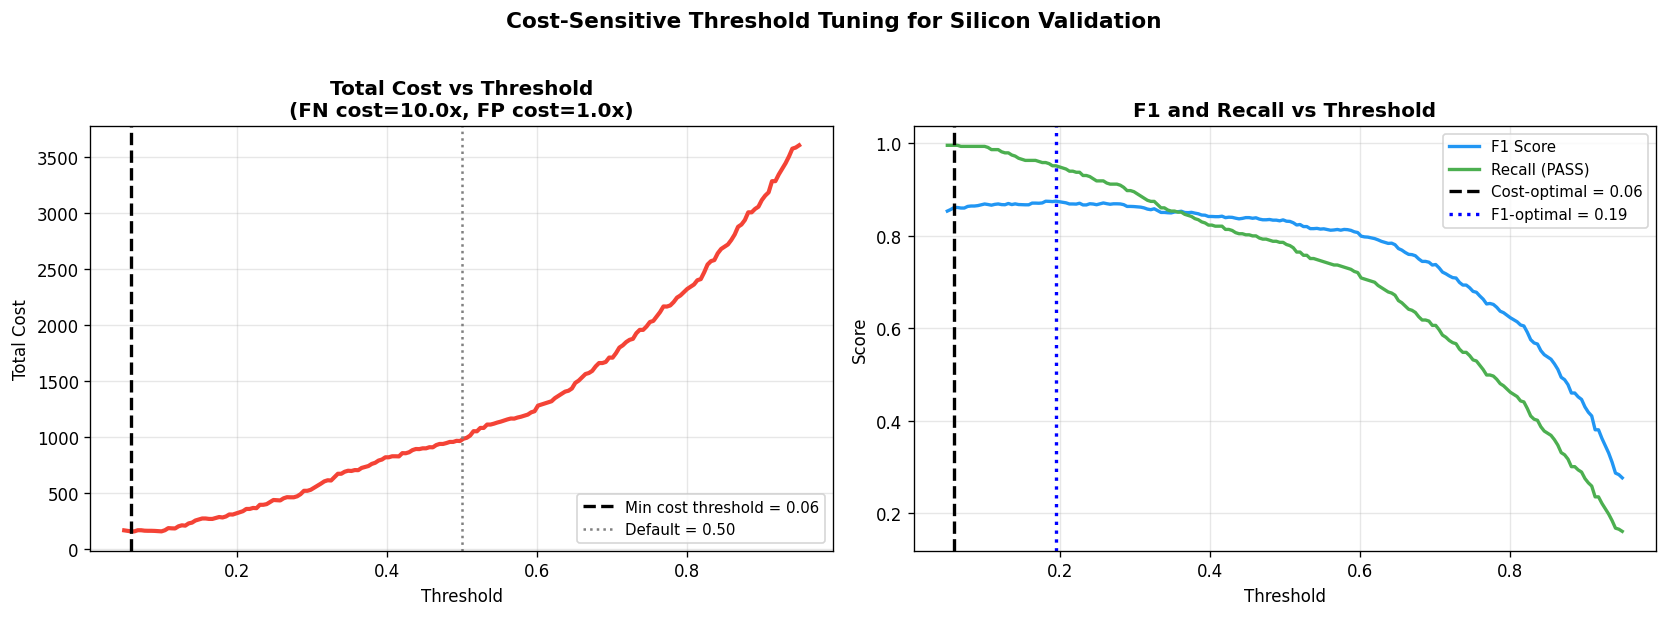

Cost-optimal threshold: 0.06 (minimizes missed failing chips)
F1-optimal threshold:   0.19

At cost-optimal threshold:
  Recall (catching FAILs): 0.2047
  F1 Score:                0.8609


In [7]:
y_prob_best = best_model.predict_proba(X_test_s)[:, 1]

# Cost matrix: FN is 10x more costly than FP
FN_COST = 10.0  # Missing a failing chip
FP_COST = 1.0   # Unnecessary re-test

thresholds = np.linspace(0.05, 0.95, 200)
costs, f1s, recalls = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * FN_COST + fp * FP_COST
    costs.append(total_cost)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t_cost = thresholds[np.argmin(costs)]
best_t_f1   = thresholds[np.argmax(f1s)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, costs, color=COLORS['fail'], linewidth=2.5)
axes[0].axvline(best_t_cost, color='black', linestyle='--', linewidth=2,
               label=f'Min cost threshold = {best_t_cost:.2f}')
axes[0].axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Default = 0.50')
axes[0].set_title(f'Total Cost vs Threshold\n(FN cost={FN_COST}x, FP cost={FP_COST}x)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Cost')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, f1s,     color=COLORS['primary'],   linewidth=2, label='F1 Score')
axes[1].plot(thresholds, recalls, color=COLORS['authentic'] if 'authentic' in COLORS else COLORS['pass'], linewidth=2, label='Recall (PASS)')
axes[1].axvline(best_t_cost, color='black', linestyle='--', linewidth=2, label=f'Cost-optimal = {best_t_cost:.2f}')
axes[1].axvline(best_t_f1,   color='blue',  linestyle=':',  linewidth=2, label=f'F1-optimal = {best_t_f1:.2f}')
axes[1].set_title('F1 and Recall vs Threshold', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Cost-Sensitive Threshold Tuning for Silicon Validation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Cost-optimal threshold: {best_t_cost:.2f} (minimizes missed failing chips)')
print(f'F1-optimal threshold:   {best_t_f1:.2f}')
print()
y_pred_cost = (y_prob_best >= best_t_cost).astype(int)
print(f'At cost-optimal threshold:')
print(f'  Recall (catching FAILs): {recall_score(y_test, y_pred_cost, pos_label=0):.4f}')
print(f'  F1 Score:                {f1_score(y_test, y_pred_cost):.4f}')

## 5. Probability Calibration

A well-calibrated model means that when it predicts P(PASS) = 0.8, approximately 80% of those chips actually pass. Logistic regression is generally well-calibrated, but regularization can distort this. We use Platt Scaling (fitting a logistic regression on top of the model's raw scores) to improve calibration and verify it with a reliability diagram.

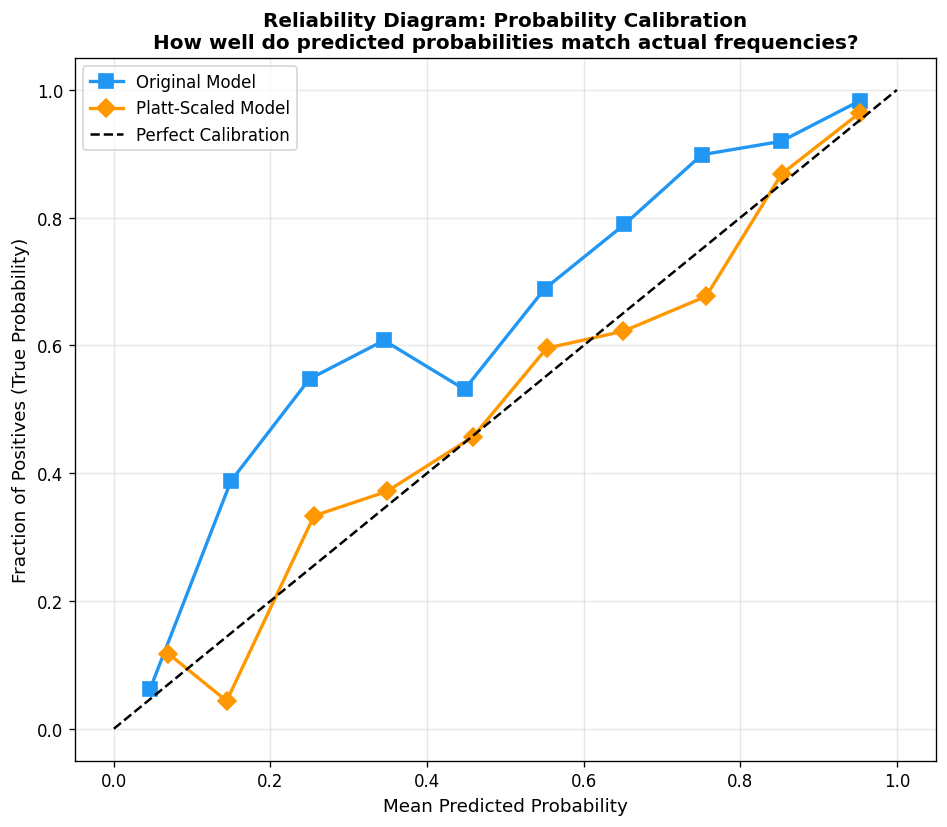

In [8]:
# Calibrated model using Platt Scaling
calibrated = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)
calibrated.fit(X_train_s, y_train)  # Cross-validated calibration on training set

fig, ax = plt.subplots(figsize=(8, 7))

# Original model calibration
prob_true, prob_pred = calibration_curve(y_test, y_prob_best, n_bins=10)
ax.plot(prob_pred, prob_true, 's-', color=COLORS['primary'], linewidth=2, markersize=8, label='Original Model')

# Calibrated model
y_prob_cal = calibrated.predict_proba(X_test_s)[:, 1]
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)
ax.plot(prob_pred_cal, prob_true_cal, 'D-', color=COLORS['secondary'], linewidth=2, markersize=8, label='Platt-Scaled Model')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives (True Probability)', fontsize=11)
ax.set_title('Reliability Diagram: Probability Calibration\nHow well do predicted probabilities match actual frequencies?', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. ROC and PR Curves

We compare all four models on the silicon dataset. In a silicon validation context, the PR curve is particularly important because we care most about the model's performance on the minority FAIL class.

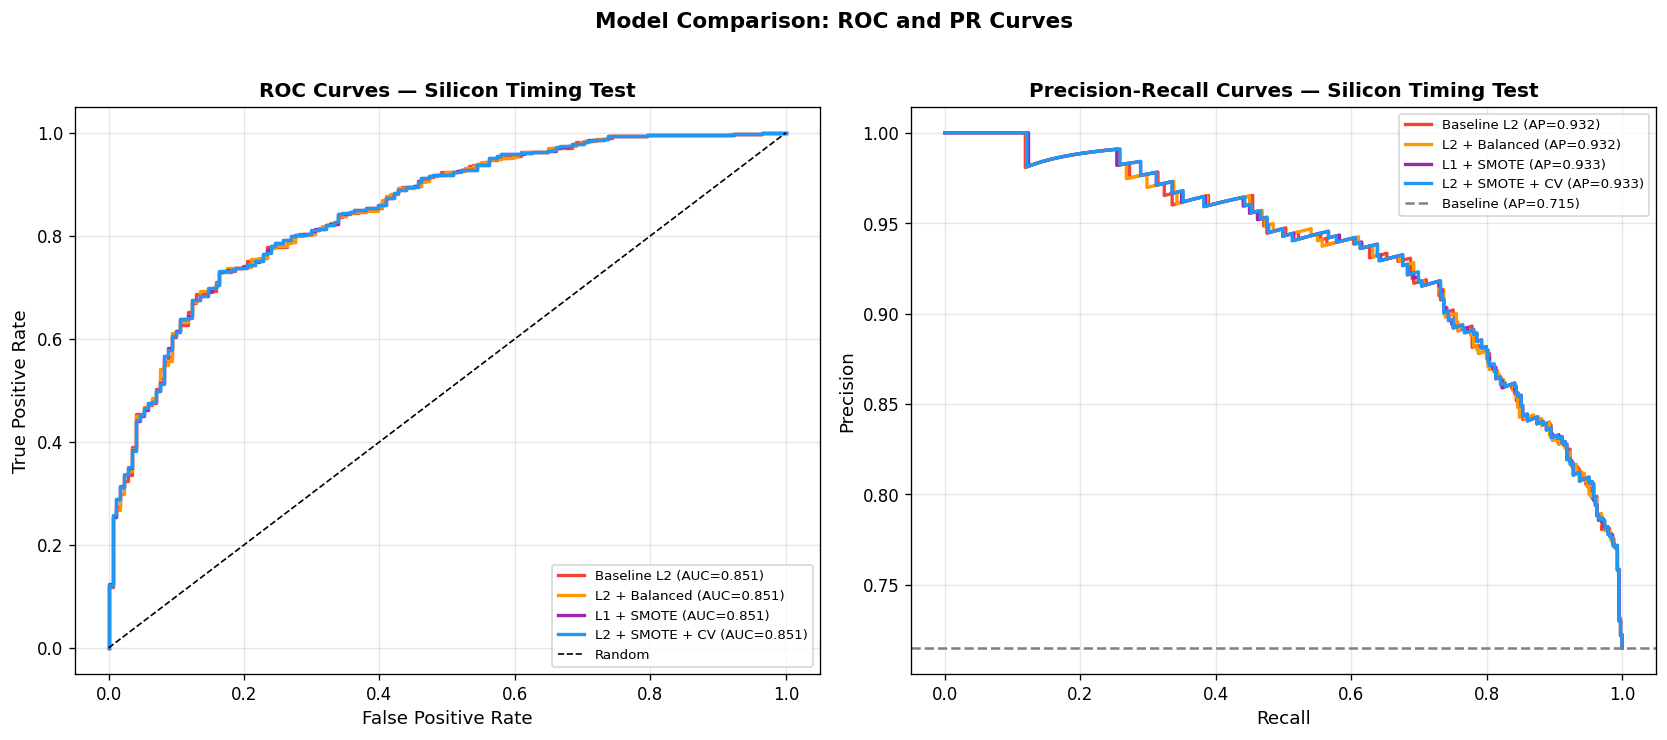

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
model_colors = [COLORS['fail'], COLORS['secondary'], '#9C27B0', COLORS['primary']]

for (name, model), color in zip(trained.items(), model_colors):
    y_prob = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--',linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — Silicon Timing Test', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(True, alpha=0.3)

for (name, model), color in zip(trained.items(), model_colors):
    y_prob = model.predict_proba(X_test_s)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

axes[1].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1.5, label=f'Baseline (AP={y_test.mean():.3f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves — Silicon Timing Test', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison: ROC and PR Curves', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Importance and Engineering Insights

The logistic regression coefficients reveal which electrical parameters most strongly predict timing failure. This is directly actionable for silicon validation engineers: features with large negative coefficients are the primary risk factors for timing failures.

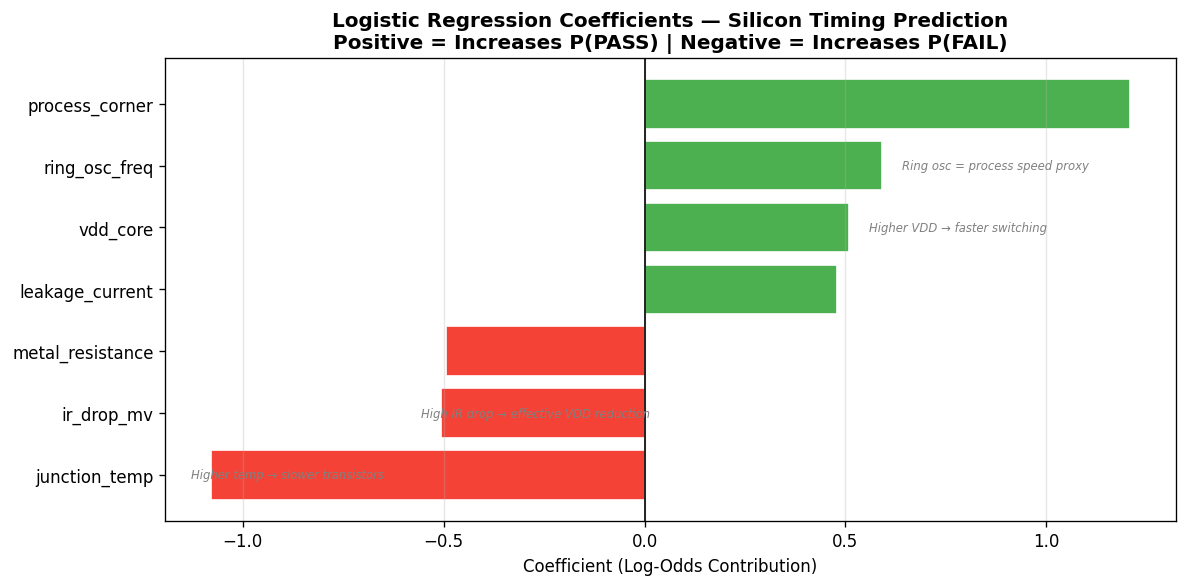

In [10]:
coefs = best_model.coef_[0]
feat_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': coefs}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [COLORS['pass'] if c > 0 else COLORS['fail'] for c in feat_df['Coefficient']]
ax.barh(feat_df['Feature'], feat_df['Coefficient'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression Coefficients — Silicon Timing Prediction\nPositive = Increases P(PASS) | Negative = Increases P(FAIL)', fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient (Log-Odds Contribution)')
ax.grid(True, alpha=0.3, axis='x')

# Engineering annotations
for i, (feat, coef) in enumerate(zip(feat_df['Feature'], feat_df['Coefficient'])):
    if abs(coef) > 0.3:
        note = ''
        if 'vdd' in feat: note = 'Higher VDD → faster switching'
        elif 'temp' in feat: note = 'Higher temp → slower transistors'
        elif 'ir_drop' in feat: note = 'High IR drop → effective VDD reduction'
        elif 'ring_osc' in feat: note = 'Ring osc = process speed proxy'
        if note:
            ax.text(coef + (0.05 if coef > 0 else -0.05), i, note, va='center',
                   fontsize=7, color='gray', style='italic')

plt.tight_layout()
plt.show()

## Summary

This notebook applied logistic regression to a real post-silicon validation problem — predicting timing test outcomes from electrical measurements.

| Concept | Silicon Validation Context |
|:---|:---|
| Class imbalance | Most chips pass; FAIL is the rare, important class |
| Cost-sensitive threshold | FN (missed fail) is 10x more costly than FP (unnecessary retest) |
| Decision boundary | Linear boundary in VDD-Temperature space matches physical intuition |
| Feature importance | VDD and ring oscillator frequency are the strongest predictors |
| Calibration | Well-calibrated probabilities enable risk-based test prioritization |

**Engineering Impact:** A well-calibrated logistic regression model can reduce the number of physical timing tests needed by flagging high-confidence PASS predictions, reducing characterization time by 20-40% while maintaining test coverage.

**Next:** Post 3 — Tree-Based Learning (Decision Trees, Random Forests, Feature Importance)